# 타이타닉호 생존 데이터셋 분석

이 노트북에서는 타이타닉호의 생존 데이터셋을 분석하고, 남성과 여성의 생존비율을 시각화합니다.

In [1]:
# 필요한 라이브러리 임포트
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

In [2]:
# 타이타닉호 데이터셋 로드
# seaborn에 내장된 데이터셋 사용
df = sns.load_dataset('titanic')

# 데이터셋의 첫 몇 행 확인
print("데이터셋의 첫 5행:")
print(df.head())
print("\n데이터셋 정보:")
print(df.info())

데이터셋의 첫 5행:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

데이터셋 정보:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived    

In [3]:
# 데이터셋의 기본 통계
print("데이터셋 통계:")
print(df.describe())

데이터셋 통계:
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [4]:
# 성별별 생존 데이터 확인
print("성별별 생존자 수:")
survival_by_sex = pd.crosstab(df['sex'], df['survived'], margins=True)
print(survival_by_sex)

성별별 생존자 수:
survived    0    1  All
sex                    
female     81  233  314
male      468  109  577
All       549  342  891


In [5]:
# 성별별 생존비율 계산
print("성별별 생존비율 (%):\n")
survival_rate = df.groupby('sex')['survived'].agg(['sum', 'count'])
survival_rate['survival_rate'] = (survival_rate['sum'] / survival_rate['count'] * 100).round(2)
survival_rate.columns = ['생존자 수', '전체 인원', '생존비율(%)']
print(survival_rate)

성별별 생존비율 (%):

        생존자 수  전체 인원  생존비율(%)
sex                          
female    233    314    74.20
male      109    577    18.89


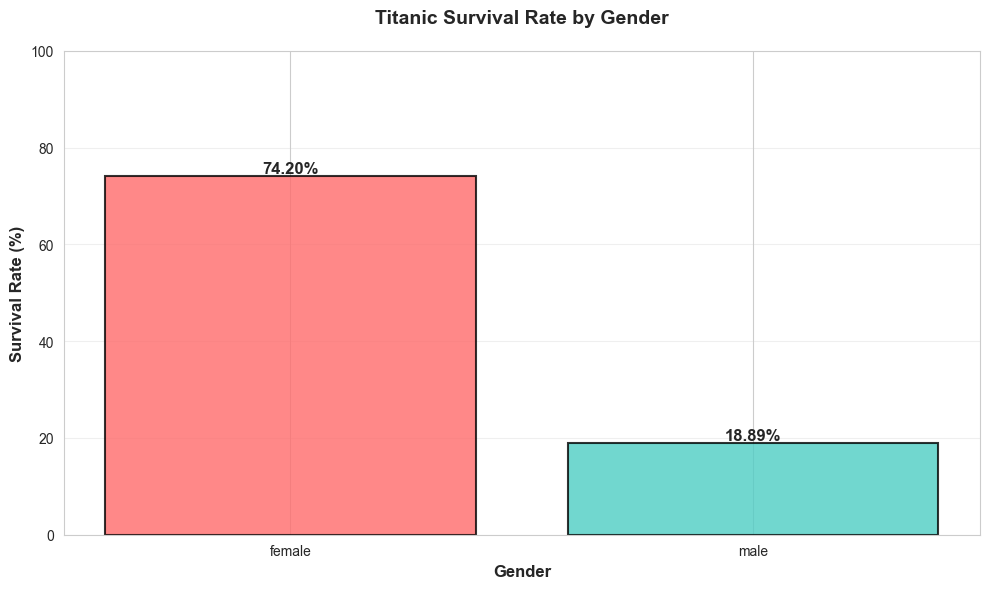


생존비율:
FEMALE: 74.20%
MALE: 18.89%


In [6]:
# 성별별 생존비율 바차트 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 성별별 생존비율 계산
survival_pct = df.groupby('sex')['survived'].apply(lambda x: (x.sum() / len(x) * 100)).reset_index()
survival_pct.columns = ['sex', 'survival_rate']

# 한글 레이블로 변환
sex_labels = {'male': 'Male', 'female': 'Female'}
colors = ['#FF6B6B', '#4ECDC4']

bars = ax.bar(survival_pct['sex'], survival_pct['survival_rate'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# 바 위에 생존비율 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# 축 레이블 및 제목 설정
ax.set_ylabel('Survival Rate (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax.set_title('Titanic Survival Rate by Gender', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n생존비율:")
for idx, row in survival_pct.iterrows():
    print(f"{row['sex'].upper()}: {row['survival_rate']:.2f}%")

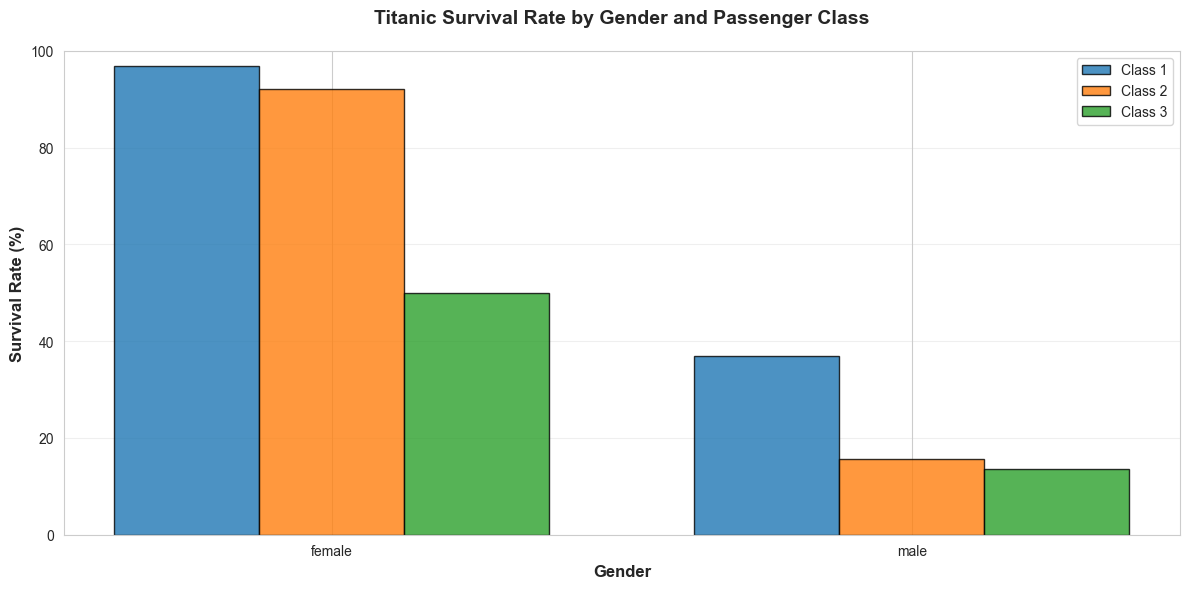

In [7]:
# 성별 및 클래스별 생존비율 분석
fig, ax = plt.subplots(figsize=(12, 6))

# 성별과 클래스별 생존비율 계산
survival_by_sex_class = df.groupby(['sex', 'pclass'])['survived'].apply(lambda x: (x.sum() / len(x) * 100)).unstack()

# 바차트 그리기
x = np.arange(len(survival_by_sex_class.index))
width = 0.25

for i, pclass in enumerate(survival_by_sex_class.columns):
    ax.bar(x + i*width, survival_by_sex_class[pclass], width, 
           label=f'Class {int(pclass)}', alpha=0.8, edgecolor='black')

ax.set_ylabel('Survival Rate (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax.set_title('Titanic Survival Rate by Gender and Passenger Class', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x + width)
ax.set_xticklabels(survival_by_sex_class.index)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# 분석 요약
print("=" * 50)
print("타이타닉호 생존 데이터 분석 요약")
print("=" * 50)
print(f"\n전체 탑승객: {len(df):,}명")
print(f"전체 생존자: {df['survived'].sum():,}명")
print(f"전체 생존율: {(df['survived'].sum() / len(df) * 100):.2f}%")
print("\n성별별 분석:")
for sex in ['male', 'female']:
    sex_data = df[df['sex'] == sex]
    survival_rate = (sex_data['survived'].sum() / len(sex_data) * 100)
    print(f"\n{sex.upper()}:")
    print(f"  - 탑승객: {len(sex_data):,}명")
    print(f"  - 생존자: {sex_data['survived'].sum():,}명")
    print(f"  - 생존율: {survival_rate:.2f}%")

타이타닉호 생존 데이터 분석 요약

전체 탑승객: 891명
전체 생존자: 342명
전체 생존율: 38.38%

성별별 분석:

MALE:
  - 탑승객: 577명
  - 생존자: 109명
  - 생존율: 18.89%

FEMALE:
  - 탑승객: 314명
  - 생존자: 233명
  - 생존율: 74.20%
